In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df=pd.read_csv('stores_sales_forecasting.csv', encoding='latin1')
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
3       6  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   
4      11  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   

     Customer Name   Segment        Country             City  ... Postal Code  \
0      Claire Gute  Consumer  United States        Henderson  ...       42420   
1      Claire Gute  Consumer  United States        Henderson  ...       42420   
2   Sean O'Donnell  Consumer  United States  Fort Lauderdale  ...       33311   
3  Brosina Hoffman  Consumer  United States      Los Angeles  ...       90032   
4  Brosina Hoffman  Consumer  United States      Los Angeles  ...       90032   

   Region       Product ID

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [7]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [8]:
df.columns = (
      df.columns

      .str.replace(r'[^a-zA-Z0-9 ]', '', regex=True)  # remove weird symbols
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      )

print(df.columns)



Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'subcategory',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df=df.drop_duplicates()

In [11]:
print(df.head())

   row_id        order_id order_date  ship_date       ship_mode customer_id  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
3       6  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
4      11  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   

     customer_name   segment        country             city  ... postal_code  \
0      Claire Gute  Consumer  United States        Henderson  ...       42420   
1      Claire Gute  Consumer  United States        Henderson  ...       42420   
2   Sean O'Donnell  Consumer  United States  Fort Lauderdale  ...       33311   
3  Brosina Hoffman  Consumer  United States      Los Angeles  ...       90032   
4  Brosina Hoffman  Consumer  United States      Los Angeles  ...       90032   

   region       product_id   category 

In [12]:
print(df.isnull().sum())

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
subcategory      0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64


In [13]:
df['year']=df['order_date'].dt.year
df['month']=df['order_date'].dt.month
df['day']=df['order_date'].dt.day
df['day_name']=df['order_date'].dt.day_name()

In [14]:
print(df.head())

   row_id        order_id order_date  ship_date       ship_mode customer_id  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
3       6  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
4      11  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   

     customer_name   segment        country             city  ...  \
0      Claire Gute  Consumer  United States        Henderson  ...   
1      Claire Gute  Consumer  United States        Henderson  ...   
2   Sean O'Donnell  Consumer  United States  Fort Lauderdale  ...   
3  Brosina Hoffman  Consumer  United States      Los Angeles  ...   
4  Brosina Hoffman  Consumer  United States      Los Angeles  ...   

   subcategory                                       product_name      sales  \
0    Bookcases                

In [15]:
df['delivery_days']=(df['ship_date']-df['order_date']).dt.days

In [16]:
df.groupby('ship_mode')['delivery_days'].mean()

,delivery_days
ship_mode,
First Class,2.143731
Same Day,0.025210
Second Class,3.262295
Standard Class,4.976763


<Axes: xlabel='delivery_days', ylabel='profit'>

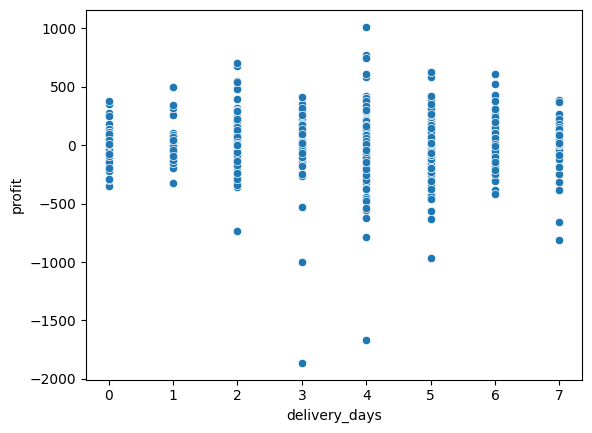

In [17]:
sns.scatterplot(x=df['delivery_days'],y=df['profit'])

In [18]:
#print(df['sales'].sum())
print(df.groupby('subcategory')['sales'].sum())

subcategory
Bookcases      114879.9963
Chairs         328449.1030
Furnishings     91705.1640
Tables         206965.5320
Name: sales, dtype: float64


In [19]:
df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head()

,sales
product_name,
HON 5400 Series Task Chairs for Big and Tall,21870.5760
"Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish",15610.9656
Bretford Rectangular Conference Table Tops,12995.2915
Global Troy Executive Leather Low-Back Tilter,12975.3820
SAFCO Arco Folding Chair,11572.7800


In [20]:
df.groupby('month')['sales'].sum().sort_values(ascending=False)

,sales
month,
12,121817.9675
11,121286.0490
9,106380.5907
10,58087.5157
6,52999.4633
3,50768.2758
7,49377.0120
5,48365.1307
8,44884.0450


In [21]:
df.groupby('day_name')['sales'].sum().sort_values(ascending=False)


,sales
day_name,
Monday,159826.6027
Friday,135657.2473
Sunday,118428.4964
Thursday,107079.8935
Saturday,102558.6280
Tuesday,85832.3452
Wednesday,32616.5822


In [22]:
df.groupby('subcategory')['discount'].mean()

,discount
subcategory,
Bookcases,0.211140
Chairs,0.170178
Furnishings,0.138349
Tables,0.261285


Text(0.5, 1.0, 'category vs sale')

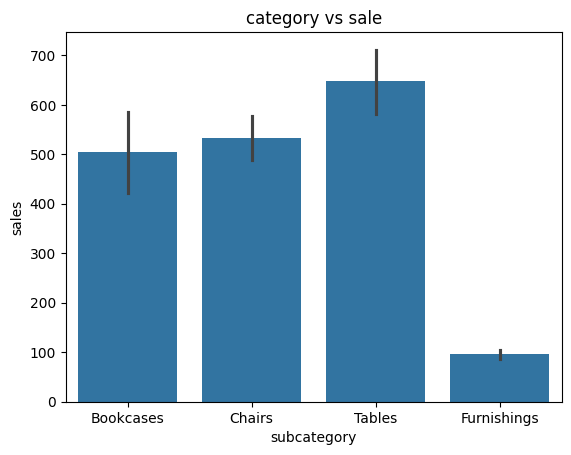

In [23]:
sns.barplot(x=df['subcategory'],y=df['sales'])
plt.title("category vs sale")


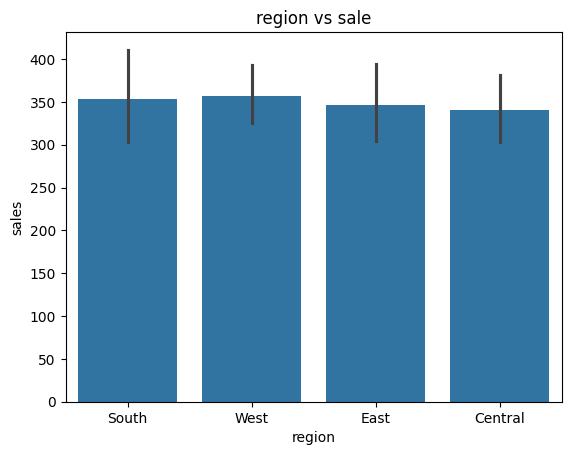

In [24]:
sns.barplot(x=df['region'],y=df['sales'])
plt.title("region vs sale")
plt.show()

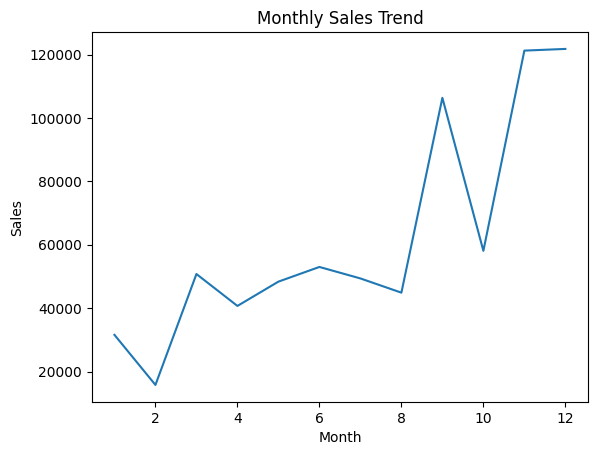

In [25]:
monthly_sales = df.groupby('month')['sales'].sum().reset_index()

plt.plot(monthly_sales['month'], monthly_sales['sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Text(0.5, 1.0, 'sales vs profit')

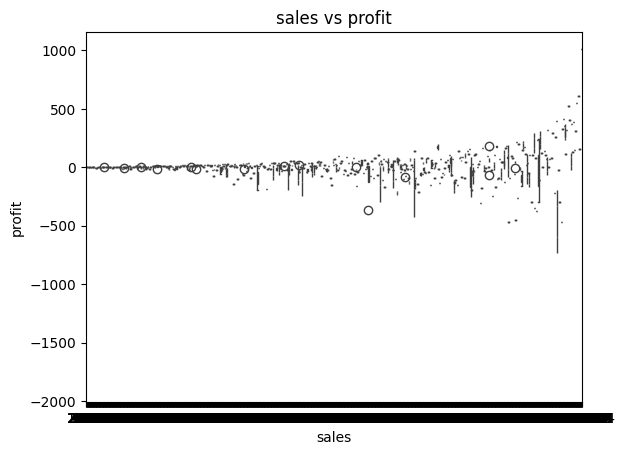

In [26]:
sns.boxplot(x=df['sales'],y=df['profit'])
plt.title('sales vs profit')

In [27]:
df['dayofweek']=df['order_date'].dt.dayofweek
features=['month','dayofweek','discount','quantity']
x=df[features]
y=df['sales']


In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()
model.fit( x_train,y_train)

RandomForestRegressor()

In [30]:
pred=model.predict(x_test)

In [31]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

RMSE: 563.691752522679


In [32]:
df.shape

(2121, 27)

In [33]:
df.isnull().sum()

,0
row_id,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
country,0
city,0


In [38]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate_model(name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name} -> R2: {r2:.3f}, RMSE: {rmse:.2f}")

            # Example usage:
            # evaluate_model("Linear", y_test, y_pred_lr)
            # evaluate_model("Random Forest", y_test, y_pred_rf)

Dataset Shape: (2121, 27)

Missing Values:
 row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
subcategory      0
product_name     0
sales            0
quantity         0
discount         0
profit           0
year             0
month            0
day              0
day_name         0
delivery_days    0
dayofweek        0
dtype: int64


In [39]:
df.groupby('month')['sales'].sum().sort_values(ascending=False)

,sales
month,
12,121817.9675
11,121286.0490
9,106380.5907
10,58087.5157
6,52999.4633
3,50768.2758
7,49377.0120
5,48365.1307
8,44884.0450


In [40]:
df[['discount','profit']].corr()

,discount,profit
discount,1.000000,-0.483769
profit,-0.483769,1.000000


In [41]:
df.groupby('category')['sales'].sum().sort_values(ascending=False)

,sales
category,
Furniture,741999.7953


In [44]:
df['subcategory'].value_counts()

,count
subcategory,
Furnishings,957
Chairs,617
Tables,319
Bookcases,228


In [49]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [50]:
# ---- Predictions ----
rf_pred = model.predict(x_test)
lr_pred = lr.predict(x_test)

# ---- Metrics ----
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

lr_r2 = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)

print("----- MODEL PERFORMANCE -----\n")

print("Random Forest:")
print(f"R² Score  : {rf_r2:.4f}")
print(f"MAE       : {rf_mae:.2f}\n")

print("Linear Regression:")
print(f"R² Score  : {lr_r2:.4f}")
print(f"MAE       : {lr_mae:.2f}\n")

# ---- Improvement ----
r2_improvement = ((rf_r2 - lr_r2) / abs(lr_r2)) * 100
mae_improvement = ((lr_mae - rf_mae) / lr_mae) * 100

print("----- IMPROVEMENT -----\n")
print(f"R² Improvement  : {r2_improvement:.2f}%")
print(f"MAE Reduction   : {mae_improvement:.2f}%")

----- MODEL PERFORMANCE -----

Random Forest:
R² Score  : -0.0370
MAE       : 317.03

Linear Regression:
R² Score  : 0.1556
MAE       : 303.44

----- IMPROVEMENT -----

R² Improvement  : -123.75%
MAE Reduction   : -4.48%
